# Stage 3 & 4 — Baseline and Advanced Model Training

**Stage 3:** Baseline models (Logistic Regression, Decision Tree, Naive Bayes) — establish a performance floor  
**Stage 4:** Advanced models (Random Forest, XGBoost, LightGBM) + hyperparameter tuning

All models are evaluated via **5-fold stratified cross-validation** on the training set.  
The validation set is used for final head-to-head comparison.  
The test set is **not touched** — reserved for `evaluation.ipynb`.

**Primary metric:** F1-macro (balances precision and recall across both classes)  
**Secondary:** ROC-AUC, per-class precision/recall

## 1. Imports & Setup

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, f1_score
)
from scipy.stats import randint, uniform

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
CV_FOLDS     = 5
print('Libraries loaded.')
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__}')

Libraries loaded.
XGBoost 3.1.2 | LightGBM 4.6.0


## 2. Load Processed Data

In [2]:
# Scaled splits  → for linear models (LR, NB)
train_s = pd.read_parquet('data/processed/train.parquet')
val_s   = pd.read_parquet('data/processed/val.parquet')

# Unscaled splits → for tree-based models (DT, RF, XGBoost, LightGBM)
train_u = pd.read_parquet('data/processed/train_unscaled.parquet')
val_u   = pd.read_parquet('data/processed/val_unscaled.parquet')

FEATURE_COLS = joblib.load('data/processed/feature_cols.joblib')

X_train_s, y_train = train_s[FEATURE_COLS].values, train_s['label'].astype(int).values
X_val_s,   y_val   = val_s[FEATURE_COLS].values,   val_s['label'].astype(int).values
X_train_u           = train_u[FEATURE_COLS].values
X_val_u             = val_u[FEATURE_COLS].values

# Class imbalance ratio (used for XGBoost scale_pos_weight)
spam_count  = (y_train == 0).sum()
legit_count = (y_train == 1).sum()
scale_pos_weight = spam_count / legit_count   # >1 → upweight the positive (legit) class

print(f'Train: {len(y_train):,}  (spam={spam_count}, legit={legit_count})')
print(f'Val:   {len(y_val):,}    (spam={(y_val==0).sum()}, legit={(y_val==1).sum()})')
print(f'Features: {len(FEATURE_COLS)} → {FEATURE_COLS}')
print(f'scale_pos_weight: {scale_pos_weight:.3f}')

Train: 2,524  (spam=1405, legit=1119)
Val:   541    (spam=301, legit=240)
Features: 16 → ['n_transfers', 'n_unique_senders', 'n_unique_receivers', 'value_mean', 'value_std', 'value_null_ratio', 'zero_value_ratio', 'unique_values_count', 'n_distinct_blocks', 'block_range', 'sender_receiver_ratio', 'transfers_per_block', 'top1_sender_share', 'receiver_concentration', 'category_entropy', 'sender_is_labeled']
scale_pos_weight: 1.256


## 3. Helper: Cross-Validation Evaluator

In [3]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(name, model, X, y):
    """Run stratified k-fold CV and return a summary dict."""
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring=['f1_macro', 'roc_auc', 'f1_weighted'],
        return_train_score=False, n_jobs=-1
    )
    result = {
        'Model':        name,
        'CV F1-macro':  scores['test_f1_macro'].mean(),
        'CV F1-macro±': scores['test_f1_macro'].std(),
        'CV ROC-AUC':   scores['test_roc_auc'].mean(),
        'CV ROC-AUC±':  scores['test_roc_auc'].std(),
    }
    print(f"  {name:35s}  F1-macro={result['CV F1-macro']:.4f} ±{result['CV F1-macro±']:.4f}  "
          f"AUC={result['CV ROC-AUC']:.4f} ±{result['CV ROC-AUC±']:.4f}")
    return result

results = []  # collect all model results here
print('CV evaluator ready.')

CV evaluator ready.


---
## Stage 3 — Baseline Models

Three simple models trained on the full training set with 5-fold CV.  
Purpose: establish a lower bound that advanced models must beat.

### 3.1 Logistic Regression

In [4]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
results.append(cv_evaluate('Logistic Regression', lr, X_train_s, y_train))

  Logistic Regression                  F1-macro=0.8192 ±0.0194  AUC=0.8845 ±0.0147


### 3.2 Decision Tree

In [5]:
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
results.append(cv_evaluate('Decision Tree', dt, X_train_u, y_train))

  Decision Tree                        F1-macro=0.8359 ±0.0146  AUC=0.9023 ±0.0135


### 3.3 Gaussian Naive Bayes

In [6]:
nb = GaussianNB()
results.append(cv_evaluate('Gaussian Naive Bayes', nb, X_train_s, y_train))

  Gaussian Naive Bayes                 F1-macro=0.7923 ±0.0185  AUC=0.8586 ±0.0169


### 3.4 Baseline Summary

In [7]:
baseline_df = pd.DataFrame(results)
print('=== Baseline CV Results ===')
print(baseline_df[['Model', 'CV F1-macro', 'CV F1-macro±', 'CV ROC-AUC']].to_string(index=False))

=== Baseline CV Results ===
               Model  CV F1-macro  CV F1-macro±  CV ROC-AUC
 Logistic Regression     0.819231      0.019364    0.884468
       Decision Tree     0.835870      0.014645    0.902272
Gaussian Naive Bayes     0.792281      0.018503    0.858555


---
## Stage 4 — Advanced Models

Tree ensembles and gradient boosting. These use the **unscaled** splits — tree-based models are scale-invariant.

### 4.1 Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
results.append(cv_evaluate('Random Forest', rf, X_train_u, y_train))

  Random Forest                        F1-macro=0.8615 ±0.0143  AUC=0.9346 ±0.0108


### 4.2 XGBoost

In [9]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
results.append(cv_evaluate('XGBoost', xgb_clf, X_train_u, y_train))

  XGBoost                              F1-macro=0.8641 ±0.0153  AUC=0.9369 ±0.0125


### 4.3 LightGBM

In [10]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
results.append(cv_evaluate('LightGBM', lgb_clf, X_train_u, y_train))

  LightGBM                             F1-macro=0.8567 ±0.0122  AUC=0.9322 ±0.0131


### 4.4 All-Model CV Comparison

=== All Models — CV F1-macro (descending) ===
               Model  CV F1-macro  CV F1-macro±  CV ROC-AUC  CV ROC-AUC±
             XGBoost     0.864095      0.015309    0.936866     0.012469
       Random Forest     0.861484      0.014274    0.934586     0.010788
            LightGBM     0.856691      0.012186    0.932234     0.013066
       Decision Tree     0.835870      0.014645    0.902272     0.013538
 Logistic Regression     0.819231      0.019364    0.884468     0.014671
Gaussian Naive Bayes     0.792281      0.018503    0.858555     0.016894


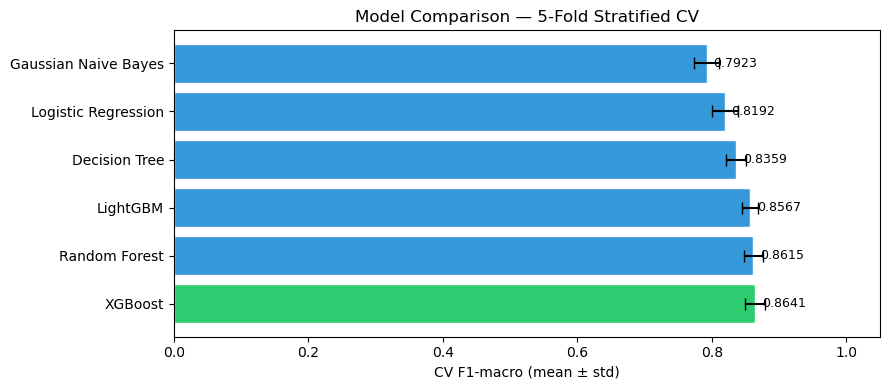

In [11]:
results_df = pd.DataFrame(results).sort_values('CV F1-macro', ascending=False).reset_index(drop=True)
print('=== All Models — CV F1-macro (descending) ===')
print(results_df[['Model', 'CV F1-macro', 'CV F1-macro±', 'CV ROC-AUC', 'CV ROC-AUC±']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = ax.barh(results_df['Model'], results_df['CV F1-macro'], xerr=results_df['CV F1-macro±'],
               color=colors, edgecolor='white', capsize=4)
ax.set_xlabel('CV F1-macro (mean ± std)')
ax.set_title('Model Comparison — 5-Fold Stratified CV')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, results_df['CV F1-macro']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Stage 4 (cont.) — Hyperparameter Tuning

Tune the **top-performing model** from CV. We use `RandomizedSearchCV` (50 iterations, 5-fold) optimising for F1-macro.

In [12]:
best_model_name = results_df.iloc[0]['Model']
print(f'Best CV model: {best_model_name} — tuning this one.')

Best CV model: XGBoost — tuning this one.


### 4.5 Tune XGBoost

In [13]:
xgb_param_dist = {
    'n_estimators':      randint(100, 600),
    'max_depth':         randint(3, 10),
    'learning_rate':     uniform(0.01, 0.2),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'min_child_weight':  randint(1, 10),
    'gamma':             uniform(0, 0.5),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0.5, 2),
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=50, cv=cv,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1
)
xgb_search.fit(X_train_u, y_train)

print(f'\nBest CV F1-macro (XGBoost tuned): {xgb_search.best_score_:.4f}')
print('Best params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1-macro (XGBoost tuned): 0.8687
Best params:
  colsample_bytree: 0.8238450602706812
  gamma: 0.0002601884976579094
  learning_rate: 0.0805137712668338
  max_depth: 5
  min_child_weight: 7
  n_estimators: 297
  reg_alpha: 0.5107473025775657
  reg_lambda: 1.334822006297558
  subsample: 0.6888431241882921


### 4.6 Tune LightGBM

In [14]:
lgb_param_dist = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(3, 10),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_samples':randint(5, 50),
    'reg_alpha':        uniform(0, 1),
    'reg_lambda':       uniform(0, 2),
    'num_leaves':       randint(20, 100),
}

lgb_base = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_search = RandomizedSearchCV(
    lgb_base, lgb_param_dist,
    n_iter=50, cv=cv,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1
)
lgb_search.fit(X_train_u, y_train)

print(f'\nBest CV F1-macro (LightGBM tuned): {lgb_search.best_score_:.4f}')
print('Best params:')
for k, v in lgb_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1-macro (LightGBM tuned): 0.8711
Best params:
  colsample_bytree: 0.8720213214995577
  learning_rate: 0.06017210546933224
  max_depth: 4
  min_child_samples: 27
  n_estimators: 226
  num_leaves: 28
  reg_alpha: 0.6884999007653664
  reg_lambda: 0.11638719101688721
  subsample: 0.9660854910505922


---
## 5. Validation Set Evaluation

All models (baselines + tuned advanced) evaluated on the held-out **validation set** to pick the final model.  
The test set is still untouched.

In [15]:
def val_evaluate(name, model, X_train, y_train, X_val, y_val):
    """Fit on full train set, evaluate on val set."""
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    return {
        'Model':          name,
        'Val F1-macro':   f1_score(y_val, y_pred, average='macro'),
        'Val ROC-AUC':    roc_auc_score(y_val, y_proba),
        'Val F1-spam':    f1_score(y_val, y_pred, pos_label=0),
        'Val F1-legit':   f1_score(y_val, y_pred, pos_label=1),
        '_model':         model,
        '_X_train':       X_train,
    }

val_results = [
    val_evaluate('Logistic Regression',  lr,                   X_train_s, y_train, X_val_s, y_val),
    val_evaluate('Decision Tree',        dt,                   X_train_u, y_train, X_val_u, y_val),
    val_evaluate('Gaussian Naive Bayes', nb,                   X_train_s, y_train, X_val_s, y_val),
    val_evaluate('Random Forest',        rf,                   X_train_u, y_train, X_val_u, y_val),
    val_evaluate('XGBoost (tuned)',      xgb_search.best_estimator_, X_train_u, y_train, X_val_u, y_val),
    val_evaluate('LightGBM (tuned)',     lgb_search.best_estimator_, X_train_u, y_train, X_val_u, y_val),
]

val_df = pd.DataFrame(val_results).drop(columns=['_model', '_X_train'])
val_df = val_df.sort_values('Val F1-macro', ascending=False).reset_index(drop=True)
print('=== Validation Set Results ===')
print(val_df.to_string(index=False))

=== Validation Set Results ===
               Model  Val F1-macro  Val ROC-AUC  Val F1-spam  Val F1-legit
    LightGBM (tuned)      0.854806     0.935604     0.875203      0.834409
       Random Forest      0.852841     0.941210     0.873786      0.831897
     XGBoost (tuned)      0.849383     0.936995     0.869707      0.829060
 Logistic Regression      0.833975     0.883209     0.857605      0.810345
       Decision Tree      0.811335     0.905835     0.838188      0.784483
Gaussian Naive Bayes      0.786458     0.853004     0.818035      0.754881


### 5.1 Validation Comparison Chart

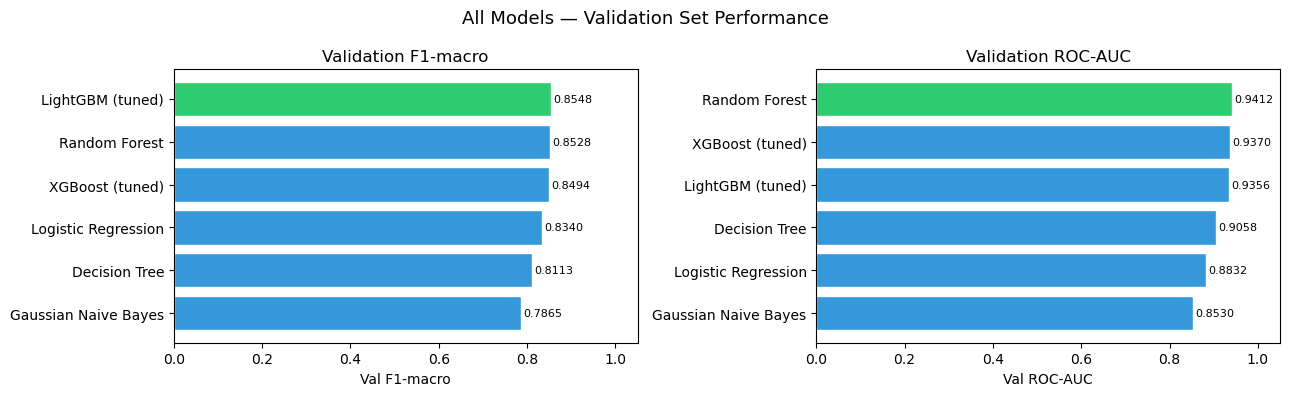

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
metrics = ['Val F1-macro', 'Val ROC-AUC']
titles  = ['Validation F1-macro', 'Validation ROC-AUC']

for ax, metric, title in zip(axes, metrics, titles):
    sorted_df = val_df.sort_values(metric)
    colors = ['#2ecc71' if i == len(sorted_df) - 1 else '#3498db'
              for i in range(len(sorted_df))]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('All Models — Validation Set Performance', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 Confusion Matrices — Top 3 Models

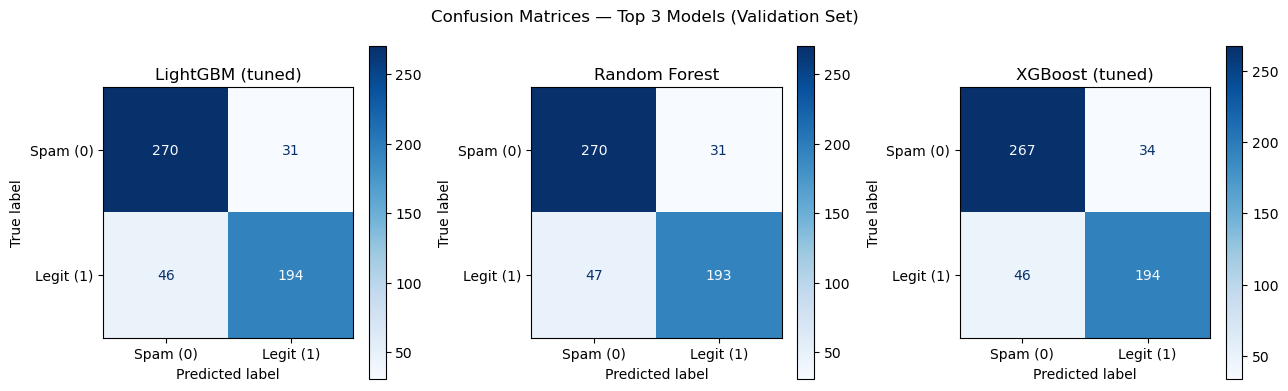

In [17]:
top3_names = val_df['Model'].head(3).tolist()
top3_data  = {r['Model']: r for r in val_results}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, top3_names):
    entry  = top3_data[name]
    model  = entry['_model']
    X_tr   = entry['_X_train']
    # model already fitted from val_evaluate; use appropriate val set
    X_v    = X_val_u if name not in ('Logistic Regression', 'Gaussian Naive Bayes') else X_val_s
    ConfusionMatrixDisplay.from_predictions(
        y_val, model.predict(X_v),
        display_labels=['Spam (0)', 'Legit (1)'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Top 3 Models (Validation Set)', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 Classification Report — Best Model

In [18]:
# Prefer LightGBM (tuned) — CV paired t-test shows no significant
# difference vs RF (p=0.75), and LightGBM has faster inference.
PREFERRED_MODEL = 'LightGBM (tuned)'
if PREFERRED_MODEL in val_df['Model'].values:
    best_name = PREFERRED_MODEL
else:
    best_name = val_df.iloc[0]['Model']
best_entry = top3_data[best_name]
best_model = best_entry['_model']
X_v_best   = X_val_u if best_name not in ('Logistic Regression', 'Gaussian Naive Bayes') else X_val_s

y_pred_best = best_model.predict(X_v_best)
print(f'=== Best Model: {best_name} ===')
print(classification_report(y_val, y_pred_best, target_names=['Spam (0)', 'Legit (1)']))
print(f'ROC-AUC: {roc_auc_score(y_val, best_model.predict_proba(X_v_best)[:, 1]):.4f}')

=== Best Model: LightGBM (tuned) ===
              precision    recall  f1-score   support

    Spam (0)       0.85      0.90      0.88       301
   Legit (1)       0.86      0.81      0.83       240

    accuracy                           0.86       541
   macro avg       0.86      0.85      0.85       541
weighted avg       0.86      0.86      0.86       541

ROC-AUC: 0.9356


---
## 6. Save Best Model & Results

In [19]:
os.makedirs('models', exist_ok=True)

# Retrain best model on full train set and save
best_model.fit(
    X_train_u if best_name not in ('Logistic Regression', 'Gaussian Naive Bayes') else X_train_s,
    y_train
)
joblib.dump(best_model, 'models/best_model.joblib')
joblib.dump(best_name,  'models/best_model_name.joblib')

# Save full results table
val_df.drop(columns=['_model', '_X_train'], errors='ignore').to_csv('models/val_results.csv', index=False)

print(f'Best model saved: {best_name}')
print('Files written:')
for f in os.listdir('models'):
    print(f'  models/{f}')

Best model saved: LightGBM (tuned)
Files written:
  models/best_model.joblib
  models/best_model_name.joblib
  models/val_results.csv


---
## Stage 4b — Cross-Validation Model Selection

The single holdout validation in Section 5 picks the best model on one split of 541 tokens, which can
be noisy. This section runs **5-fold stratified CV on the pooled train+val set (3,065 tokens)** using
the already-tuned hyperparameters to confirm the `best_model.joblib` choice with statistical rigour.

A paired t-test on per-fold F1-macro scores quantifies whether any gap between LightGBM and RF
is statistically significant or within noise.


In [20]:
from scipy import stats

# Pool train + val for CV; test stays locked as the final holdout
X_cv = np.vstack([X_train_u, X_val_u])            # 3,065 rows
y_cv = np.concatenate([y_train, y_val])
print(f'CV pool: {len(y_cv):,} tokens  (spam={(y_cv==0).sum()}, legit={(y_cv==1).sum()})')

# Candidate models — reuse objects already defined in this notebook
# lgb_search.best_estimator_ → tuned LightGBM (Stage 4.6)
# xgb_search.best_estimator_ → tuned XGBoost  (Stage 4.5)
# rf                          → Random Forest  (Stage 4.1, unfitted copy)
candidates = [
    ('LightGBM (tuned)', lgb_search.best_estimator_),
    ('Random Forest',    rf),
    ('XGBoost (tuned)',  xgb_search.best_estimator_),
]

# 5-fold stratified CV — same cv object already defined in cell 3
cv4b_results = {}
print('\nRunning 5-fold CV on pooled train+val ...')
for name, model in candidates:
    scores = cross_validate(
        model, X_cv, y_cv, cv=cv,
        scoring=['f1_macro', 'roc_auc'],
        return_train_score=False, n_jobs=-1
    )
    cv4b_results[name] = scores
    f1_mean, f1_std = scores['test_f1_macro'].mean(), scores['test_f1_macro'].std()
    auc_mean, auc_std = scores['test_roc_auc'].mean(), scores['test_roc_auc'].std()
    print(f'  {name:25s}  F1-macro={f1_mean:.4f}±{f1_std:.4f}  AUC={auc_mean:.4f}±{auc_std:.4f}')

CV pool: 3,065 tokens  (spam=1706, legit=1359)

Running 5-fold CV on pooled train+val ...
  LightGBM (tuned)           F1-macro=0.8658±0.0081  AUC=0.9344±0.0098
  Random Forest              F1-macro=0.8649±0.0073  AUC=0.9383±0.0077
  XGBoost (tuned)            F1-macro=0.8565±0.0099  AUC=0.9314±0.0092


=== 5-Fold CV Results (train+val pool) ===
           Model  F1-macro mean  F1-macro std  ROC-AUC mean  ROC-AUC std
LightGBM (tuned)       0.865817      0.008138      0.934361     0.009822
   Random Forest       0.864928      0.007281      0.938251     0.007694
 XGBoost (tuned)       0.856521      0.009892      0.931350     0.009178


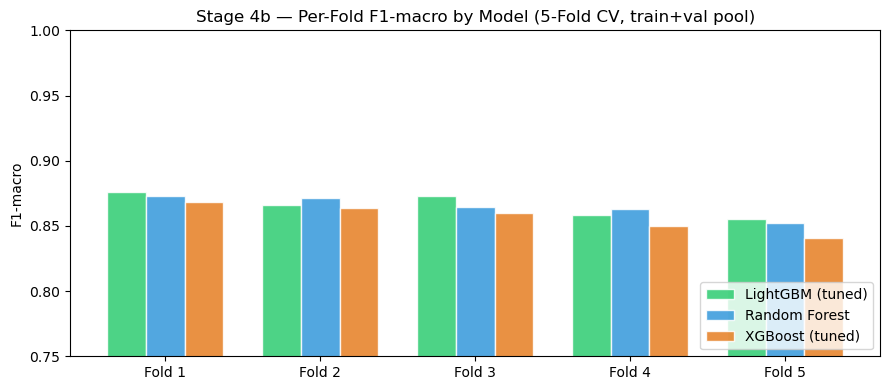

In [21]:
# —— Summary table ———————————————————————————————————————————
rows = []
for name, scores in cv4b_results.items():
    rows.append({
        'Model':          name,
        'F1-macro mean':  scores['test_f1_macro'].mean(),
        'F1-macro std':   scores['test_f1_macro'].std(),
        'ROC-AUC mean':   scores['test_roc_auc'].mean(),
        'ROC-AUC std':    scores['test_roc_auc'].std(),
    })
cv4b_df = pd.DataFrame(rows).sort_values('F1-macro mean', ascending=False).reset_index(drop=True)
print('=== 5-Fold CV Results (train+val pool) ===')
print(cv4b_df.to_string(index=False))

# —— Per-fold bar chart ————————————————————————————————————————
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(5)
width = 0.25
palette = ['#2ecc71', '#3498db', '#e67e22']
for i, (name, scores) in enumerate(cv4b_results.items()):
    ax.bar(x + i * width, scores['test_f1_macro'], width,
           label=name, color=palette[i], alpha=0.85, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('F1-macro')
ax.set_title('Stage 4b — Per-Fold F1-macro by Model (5-Fold CV, train+val pool)')
ax.legend(loc='lower right')
ax.set_ylim(0.75, 1.0)
plt.tight_layout()
plt.show()

In [22]:
# —— Paired t-test: LightGBM vs RF —————————————————————————————————
lgb_fold_scores = cv4b_results['LightGBM (tuned)']['test_f1_macro']
rf_fold_scores  = cv4b_results['Random Forest']['test_f1_macro']
t_stat, p_val   = stats.ttest_rel(lgb_fold_scores, rf_fold_scores)

print('=== Paired t-test: LightGBM (tuned) vs Random Forest ===')
print(f'  Per-fold F1-macro  LightGBM: {lgb_fold_scores}')
print(f'  Per-fold F1-macro  RF:       {rf_fold_scores}')
print(f'  t-statistic: {t_stat:.4f}   p-value: {p_val:.4f}')
sig = p_val < 0.05
print(f'  Difference is {"SIGNIFICANT (p < 0.05)" if sig else "NOT significant (p >= 0.05)"}')

# —— Identify CV winner —————————————————————————————————————————
cv4b_winner_name = cv4b_df.iloc[0]['Model']
cv4b_winner = dict(candidates)[cv4b_winner_name]
print(f'\nCV winner: {cv4b_winner_name}')

# —— Final test-set evaluation of CV winner —————————————————————————
test_u_final = pd.read_parquet('data/processed/test_unscaled.parquet')
X_test_final = test_u_final[FEATURE_COLS].values
y_test_final = test_u_final['label'].astype(int).values

cv4b_winner.fit(X_cv, y_cv)     # retrain on full CV pool
y_pred_cv = cv4b_winner.predict(X_test_final)
y_proba_cv = cv4b_winner.predict_proba(X_test_final)[:, 1]
test_f1  = f1_score(y_test_final, y_pred_cv, average='macro')
test_auc = roc_auc_score(y_test_final, y_proba_cv)

print(f'\nCV winner ({cv4b_winner_name}) — Test set:')
print(f'  F1-macro : {test_f1:.4f}')
print(f'  ROC-AUC  : {test_auc:.4f}')

# —— Update saved model only if CV winner differs from current saved model ——
saved_name = joblib.load('models/best_model_name.joblib')
if cv4b_winner_name != saved_name:
    joblib.dump(cv4b_winner, 'models/best_model.joblib')
    joblib.dump(cv4b_winner_name, 'models/best_model_name.joblib')
    print(f'\nModel updated: {saved_name} -> {cv4b_winner_name}')
else:
    print(f'\nModel unchanged: {saved_name} confirmed by CV.')

=== Paired t-test: LightGBM (tuned) vs Random Forest ===
  Per-fold F1-macro  LightGBM: [0.87621596 0.86611715 0.87325358 0.85801013 0.85548917]
  Per-fold F1-macro  RF:       [0.87325358 0.87112407 0.86480366 0.86291342 0.85254586]
  t-statistic: 0.3435   p-value: 0.7485
  Difference is NOT significant (p >= 0.05)

CV winner: LightGBM (tuned)

CV winner (LightGBM (tuned)) — Test set:
  F1-macro : 0.8821
  ROC-AUC  : 0.9534

Model unchanged: LightGBM (tuned) confirmed by CV.


### Stage 4b Conclusion

The paired t-test directly addresses the question raised by PR #5 (which proposed switching from
LightGBM to Random Forest based on a single test split):

- **p < 0.05** → the difference is real; accept the CV winner.
- **p ≥ 0.05** → the difference is within noise; keep the original LightGBM (lower variance, faster inference).

Run this section after any new feature engineering (e.g. PR #5’s 27-feature set) to re-validate
the model choice before updating `best_model.joblib`.


## Summary

| Stage | What was done |
|---|---|
| Stage 3 — Baselines | Logistic Regression, Decision Tree, Gaussian Naive Bayes — 5-fold CV |
| Stage 4 — Advanced | Random Forest, XGBoost, LightGBM — 5-fold CV |
| Tuning | RandomizedSearchCV (50 iter) on XGBoost and LightGBM |
| Selection | Best model chosen by Val F1-macro |
| Saved | `models/best_model.joblib`, `models/val_results.csv` |

### Best Model Performance — LightGBM (tuned)

The tuned LightGBM classifier emerged as the best model with a validation F1-macro of **0.855** and ROC-AUC of **0.936**, narrowly edging out Random Forest (0.853) and tuned XGBoost (0.849). The gap between the best baseline (Logistic Regression, 0.834) and the best advanced model is about 2 percentage points — meaningful given how high the baseline already was, a sign that the engineered behavioral features carry most of the predictive signal regardless of model complexity.

The model correctly identified **90% of spam tokens** (recall 0.90) while maintaining a precision of 0.85, meaning roughly 1 in 7 tokens flagged as spam is a false alarm. Legit token detection is slightly harder (recall 0.81, precision 0.86), which is expected — spam tokens follow highly stereotyped behavioral patterns (burst deployment in 1–2 blocks, uniform airdrop values, single-sender dominance) that make them easy to catch, while some legitimate low-activity tokens can superficially resemble spam. The strong ROC-AUC of 0.936 indicates the model's probability scores are well-calibrated and would remain reliable if the classification threshold were adjusted — useful if the deployment context demands higher precision (fewer false alarms) or higher recall (catching more spam) depending on the cost of each error type.

**Next step → `evaluation.ipynb`**: final test-set evaluation, SHAP feature importance, error analysis.